# Manufacturing Production

## Goal

Explore the distribution of the cleaned **monthly** observations for Manufacturing Production.
Each value has equal weight within this native series. The notebook is independent of the other analysis notebooks.

## Context & Methods

- Read the cleaned CSV and its metadata/audit directly; cleaning remains outside this notebook.
- Use original cleaned levels, not growth rates or standardized values. No observations are filled, resampled, trimmed, or winsorized.
- The histogram covers the entire retained range. Automatic bin edges use NumPy's `auto` rule, capped at 80 bins for readability.
- The box spans the 25th to 75th percentile; its line is the median. Whiskers extend to observations within 1.5 interquartile ranges of the box. Points beyond them are shown, not deleted or declared erroneous.
- This is a full-history empirical distribution. Trends and changing conditions can shape it; it is not a fitted probability model or a stationary benchmark.
- The project does not record measurement units explicitly. Axes therefore say **native file units** rather than guessing units or an index base.

Run all cells with the packages in `requirements-notebook.txt`. Paths work from this folder or the project root.

## Setup

In [1]:
SERIES_ID = 'IPMAN'
DISPLAY_NAME = 'Manufacturing Production'
MAX_BINS = 80

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/cleaned/series_metadata.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Run from the project or a notebook subfolder.')
OUT = ROOT / 'outputs/distributions' / SERIES_ID
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'figure.facecolor':'white'})

## Data

### Load the cleaned native series

In [2]:
metadata_path = ROOT / 'data/cleaned/series_metadata.csv'
audit_path = ROOT / 'data/audit/data_cleaning_audit.csv'
metadata = pd.read_csv(metadata_path)
audit = pd.read_csv(audit_path)
assert metadata.series_id.is_unique and audit.series_id.is_unique
meta = metadata.set_index('series_id').loc[SERIES_ID]
quality = audit.set_index('series_id').loc[SERIES_ID]
if quality.status == 'FAILED':
    raise ValueError(f'Cleaning failed for {SERIES_ID}; resolve its audit before plotting.')
source = (ROOT / str(meta.clean_file).replace(chr(92), '/')).resolve()
assert source.is_relative_to((ROOT / 'data/cleaned').resolve()) and source.is_file()
input_hashes = {p.relative_to(ROOT).as_posix(): hashlib.sha256(p.read_bytes()).hexdigest()
                for p in [metadata_path, audit_path, source]}
data = pd.read_csv(source, parse_dates=['date'])
assert list(data.columns) == ['date','value']
assert pd.api.types.is_datetime64_any_dtype(data.date)
assert data.date.notna().all() and data.date.is_unique and data.date.is_monotonic_increasing
assert pd.api.types.is_numeric_dtype(data.value)
assert len(data) > 0 and np.isfinite(data.value.to_numpy()).all(), 'Resolve non-finite values in the cleaning pipeline.'
values = data.value
assert len(values) == int(quality.valid_observations) == int(meta.valid_observations)
start, end = data.date.min(), data.date.max()
coverage = pd.DataFrame([{'Dataset':DISPLAY_NAME,'Source':meta.source,
    'Expected frequency':meta.expected_frequency,'Inferred frequency':meta.inferred_frequency,
    'Start date':start.date(),'End date':end.date(),'Observations':len(values),
    'Clean missing values':int(values.isna().sum())}])
display(coverage.T.rename(columns={0:'Value'}))
if quality.status == 'WARNING':
    display(Markdown('**Existing cleaning note:** ' + str(quality.warning)))
display(Markdown('Source: `' + source.relative_to(ROOT).as_posix() + '`. Dates and values are preserved.'))

,Value
Dataset,Manufacturing Production
Source,FRED
Expected frequency,monthly
Inferred frequency,monthly
Start date,1972-01-01
End date,2026-07-01
Observations,655
Clean missing values,0


Source: `data/cleaned/IPMAN.csv`. Dates and values are preserved.

## Results

### Descriptive statistics

In [3]:
summary = values.describe(percentiles=[.25,.5,.75]).rename(index={
    'count':'Observations','mean':'Mean','std':'Sample standard deviation','min':'Minimum',
    '25%':'25th percentile','50%':'Median','75%':'75th percentile','max':'Maximum'}).to_frame('Value')
display(summary.style.format({'Value':'{:,.4f}'}))
summary.to_csv(OUT / 'summary_statistics.csv')
coverage.to_csv(OUT / 'coverage.csv',index=False)

,Value
Observations,655.0000
Mean,75.4622
Sample standard deviation,23.5627
Minimum,35.3608
25th percentile,50.7723
Median,86.2344
75th percentile,97.9543
Maximum,106.6125


### Histogram and box plot

The histogram counts observed values, including extreme observations. The box plot shares the same horizontal scale so the full range and central spread can be compared directly.

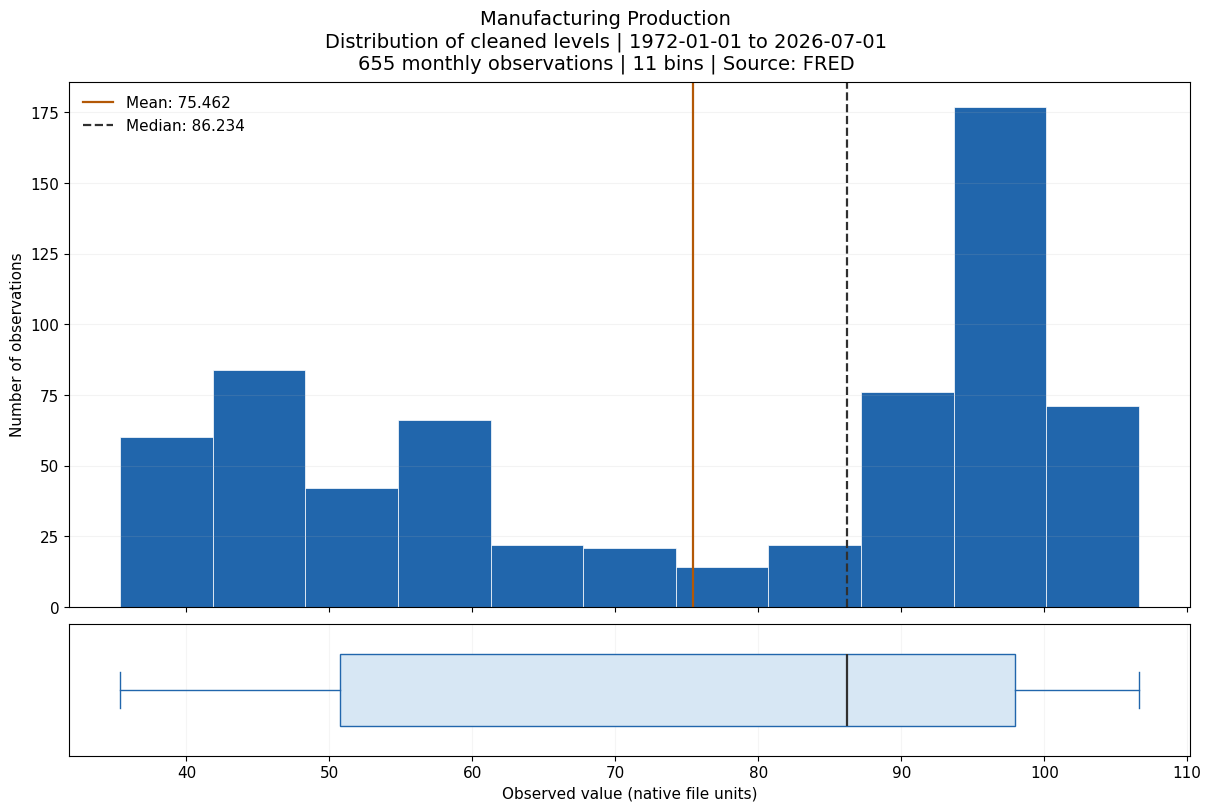

In [4]:
edges = np.histogram_bin_edges(values.to_numpy(), bins='auto')
if len(edges)-1 > MAX_BINS:
    edges = np.linspace(values.min(), values.max(), MAX_BINS+1)
counts, edges = np.histogram(values.to_numpy(), bins=edges)
assert int(counts.sum()) == len(values)
histogram = pd.DataFrame({'left_edge':edges[:-1],'right_edge':edges[1:],'observations':counts})
histogram.to_csv(OUT / 'histogram_counts.csv',index=False)
fig, (ax_hist, ax_box) = plt.subplots(2,1,figsize=(12,8),sharex=True,
    gridspec_kw={'height_ratios':[4,1]},layout='constrained')
ax_hist.hist(values,bins=edges,color='#2166AC',edgecolor='white',linewidth=.5)
ax_hist.axvline(values.mean(),color='#B35806',linewidth=1.6,label=f'Mean: {values.mean():,.3f}')
ax_hist.axvline(values.median(),color='#303030',ls='--',linewidth=1.6,label=f'Median: {values.median():,.3f}')
ax_hist.set_ylabel('Number of observations')
ax_hist.set_ylim(bottom=0)
ax_hist.grid(axis='y',alpha=.15)
ax_hist.legend(frameon=False)
ax_box.boxplot(values,vert=False,patch_artist=True,widths=.55,
    boxprops={'facecolor':'#D7E7F4','edgecolor':'#2166AC'},
    medianprops={'color':'#303030','linewidth':1.6},
    whiskerprops={'color':'#2166AC'},capprops={'color':'#2166AC'},
    flierprops={'marker':'o','markersize':3,'markerfacecolor':'none','markeredgecolor':'#2166AC'})
ax_box.set_yticks([])
ax_box.set_xlabel('Observed value (native file units)')
ax_box.grid(axis='x',alpha=.12)
fig.suptitle(textwrap.fill(DISPLAY_NAME,70) + '\nDistribution of cleaned levels | '
             + f'{start:%Y-%m-%d} to {end:%Y-%m-%d}\n'
             + f'{len(values):,} {meta.expected_frequency} observations | {len(counts)} bins | Source: {meta.source}',fontsize=14)
fig.savefig(OUT / 'distribution.png',dpi=140,bbox_inches='tight',facecolor='white')
plt.show()
plt.close(fig)

## Checks & Takeaways

In [5]:
for relative, fingerprint in input_hashes.items():
    assert hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() == fingerprint
assert counts.sum() == len(data)
assert summary.loc['Minimum','Value'] <= summary.loc['Median','Value'] <= summary.loc['Maximum','Value']
provenance = {'series_id':SERIES_ID,'title':DISPLAY_NAME,'executed_utc':datetime.now(timezone.utc).isoformat(),
    'frequency':meta.expected_frequency,'transformation':'none; cleaned native levels',
    'observations':len(values),'histogram_bin_count':len(counts),'bin_rule':'numpy auto, capped at MAX_BINS',
    'max_bins':MAX_BINS,'source_hashes_sha256':input_hashes}
(OUT / 'provenance.json').write_text(json.dumps(provenance,indent=2),encoding='utf-8')
display(Markdown(
    f'**{len(values):,} observations** are plotted over the full retained range, '
    f'**{values.min():,.3f} to {values.max():,.3f}**, with a median of **{values.median():,.3f}**. '
    'Mean and median summarize the pooled history; their positions do not establish normality or stationarity. '
    'Points beyond the box-plot whiskers remain in the data.'))
print(f'Validated histogram count and unchanged source files. Exports: {OUT}')

**655 observations** are plotted over the full retained range, **35.361 to 106.612**, with a median of **86.234**. Mean and median summarize the pooled history; their positions do not establish normality or stationarity. Points beyond the box-plot whiskers remain in the data.

Validated histogram count and unchanged source files. Exports: C:\Users\HYPE AMD\Desktop\CHronoZ-Economic-Modelling\outputs\distributions\IPMAN
